# ATLAS Wind plotting

This notebook creates wind maps from the final integrated wind NetCDF files.

It is designed as a user friendly template. The only section that normally needs editing is **1. User settings**.

Expected inputs are NetCDF files produced by the wind scaling workflow, for example:

```text
10m_wind_integrated_chile_m11_continental.nc
10m_wind_integrated_chile_m11_islands.nc
```

The notebook produces PNG figures for wind speed and wind direction.

## 0. Load libraries

Run this cell first. It imports the Python packages used for reading NetCDF files, reading the boundary shapefile and drawing maps.

In [1]:
from pathlib import Path
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rioxarray  # noqa: F401. Needed to activate the .rio accessor in xarray
import xarray as xr

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.colors import LinearSegmentedColormap, Normalize

warnings.filterwarnings("ignore")

ERROR 1: PROJ: proj_create_from_database: Open of /home/alessandrom/anaconda3/envs/bias_correction_conda/share/proj failed


## 1. User settings

Edit only this cell for a new country, month or folder structure.

Use relative paths where possible. This makes the notebook portable and avoids exposing local machine folders.

In [2]:
# Country or area name used in the input and output file names.
COUNTRY = "chile"

# Month to plot. Use integers from 1 to 12.
MONTH = 1

# Main project folder. Keep this relative unless you have a specific reason to use an absolute path.
PROJECT_DIR = Path("../data")

# Folder containing the final integrated wind NetCDF files.
INPUT_DIR = PROJECT_DIR / "atlas_data" / COUNTRY

# Folder containing the administrative boundary or study area shapefile.
# Replace the example file name with the shapefile used in your project.
BOUNDARY_FILE = PROJECT_DIR / "shapefiles" / COUNTRY / "REGIONES_v1.shp"

# Folder where the figures will be saved.
FIGURE_DIR = PROJECT_DIR / "figures" / COUNTRY
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Input files.
CONTINENTAL_FILE = INPUT_DIR / f"10m_wind_integrated_{COUNTRY}_m{MONTH}_continental.nc"
ISLANDS_FILE = INPUT_DIR / f"10m_wind_integrated_{COUNTRY}_m{MONTH}_islands.nc"

# Output figures.
WIND_SPEED_FIGURE = FIGURE_DIR / f"wds_integrated_{COUNTRY}_m{MONTH}.png"
WIND_DIRECTION_FIGURE = FIGURE_DIR / f"dir_integrated_{COUNTRY}_m{MONTH}.png"

# Optional inset maps for islands or small detached areas.
# Each entry is: name, [lon_min, lon_max, lat_min, lat_max]
# Leave this list empty if there are no islands or detached areas to show.
INSET_AREAS = [
    ("Juan Fernandez", [-80.9, -78.7, -34.1, -33.5]),
    ("Desventuradas", [-80.2, -79.85, -26.36, -26.25]),
    ("Rapa Nui", [-109.6, -109.1, -27.4, -26.9]),
]

# Set to False if you do not have an islands file or if you do not want inset maps.
USE_ISLANDS = True

## 2. Read input data

This cell opens the boundary shapefile and the NetCDF files.

The notebook assumes coordinates are in WGS84, EPSG:4326.

In [3]:
def check_file_exists(path):
    """Stop the notebook with a clear message if a required file is missing."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    return path


def open_wind_dataset(path):
    """Open a wind NetCDF file and attach the EPSG:4326 coordinate reference system."""
    path = check_file_exists(path)
    ds = xr.open_dataset(path).rio.write_crs("EPSG:4326")
    return ds


# Read the study area boundary.
check_file_exists(BOUNDARY_FILE)
boundaries = gpd.read_file(BOUNDARY_FILE).to_crs("EPSG:4326")
geometries = boundaries.geometry

# Read the gridded wind products.
xdf_continent = open_wind_dataset(CONTINENTAL_FILE)

if USE_ISLANDS:
    xdf_islands = open_wind_dataset(ISLANDS_FILE)
else:
    xdf_islands = None

print("Input data loaded successfully.")
print(f"Continental file: {CONTINENTAL_FILE}")
if USE_ISLANDS:
    print(f"Islands file: {ISLANDS_FILE}")

Input data loaded successfully.
Continental file: ../data/atlas_data/chile/10m_wind_integrated_chile_m1_continental.nc
Islands file: ../data/atlas_data/chile/10m_wind_integrated_chile_m1_islands.nc


## 3. Define colour maps

These colour maps are used for wind speed and wind direction. You can replace them with any Matplotlib colour map if needed.

In [4]:
wind_speed_colors = [
    "#f5f5f5",
    "#d9e8f5",
    "#a8cce8",
    "#74aadc",
    "#4685c4",
    "#2f60a8",
    "#1e3f82",
    "#150f5c",
    "#0b0030",
]

wind_direction_colors = [
    "#5b1f49",
    "#416a9d",
    "#a6bdca",
    "#cdb7ad",
    "#b99d9d",
    "#8c6375",
    "#5b1f49",
]

wind_speed_cmap = LinearSegmentedColormap.from_list(
    "wind_speed",
    wind_speed_colors,
    N=256,
)

wind_direction_cmap = LinearSegmentedColormap.from_list(
    "wind_direction",
    wind_direction_colors,
    N=256,
)

## 4. Helper functions

These functions keep the plotting cells short and easier to read.

In [5]:
def detect_coordinate_names(ds):
    """Return the longitude and latitude coordinate names used by a Dataset or DataArray."""
    lon_candidates = ["longitude", "lon", "x"]
    lat_candidates = ["latitude", "lat", "y"]

    lon_name = next((name for name in lon_candidates if name in ds.coords), None)
    lat_name = next((name for name in lat_candidates if name in ds.coords), None)

    if lon_name is None or lat_name is None:
        raise ValueError(
            "Could not find longitude and latitude coordinates. "
            "Expected names such as longitude/latitude or lon/lat."
        )

    return lon_name, lat_name


def cell_edges(coord):
    """Convert cell centre coordinates into cell edge coordinates for pcolormesh."""
    coord = np.asarray(coord, dtype=float)

    if coord.size < 2:
        raise ValueError("At least two coordinate values are required to compute cell edges.")

    d = np.diff(coord)
    edges = np.empty(coord.size + 1)
    edges[1:-1] = coord[:-1] + d / 2
    edges[0] = coord[0] - d[0] / 2
    edges[-1] = coord[-1] + d[-1] / 2

    return edges


def subset_by_extent(data, extent):
    """Subset a Dataset or DataArray using [lon_min, lon_max, lat_min, lat_max]."""
    lon_name, lat_name = detect_coordinate_names(data)
    xmin, xmax, ymin, ymax = extent

    lat_values = data[lat_name].values
    if lat_values[0] > lat_values[-1]:
        lat_slice = slice(ymax, ymin)
    else:
        lat_slice = slice(ymin, ymax)

    return data.sel(
        {lon_name: slice(xmin, xmax), lat_name: lat_slice}
    )


def prepare_spatial_data(data):
    """Sort data and set spatial dimensions for rioxarray operations."""
    lon_name, lat_name = detect_coordinate_names(data)

    data = data.sortby(lat_name).sortby(lon_name)
    data = data.rio.set_spatial_dims(x_dim=lon_name, y_dim=lat_name)
    data = data.rio.write_crs("EPSG:4326")

    return data, lon_name, lat_name


def get_variable(ds, variable_name):
    """Extract a variable from a Dataset or return the DataArray unchanged."""
    if isinstance(ds, xr.DataArray):
        return ds

    if variable_name not in ds:
        available = ", ".join(list(ds.data_vars))
        raise KeyError(
            f"Variable '{variable_name}' not found. Available variables are: {available}"
        )

    return ds[variable_name]


def plot_inset(ax, data, title, extent, cmap, norm, variable_name):
    """Plot one inset map for an island or detached area."""
    data = get_variable(data, variable_name)
    data = subset_by_extent(data, extent)
    data, lon_name, lat_name = prepare_spatial_data(data)

    data.plot.pcolormesh(
        ax=ax,
        x=lon_name,
        y=lat_name,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        add_colorbar=False,
    )

    boundaries.boundary.plot(
        ax=ax,
        edgecolor="black",
        linewidth=0.8,
        transform=ccrs.PlateCarree(),
    )

    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_title(title, fontsize=12, pad=2)

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.3,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}

## 5. Main plotting function

This function draws the continental map, optional inset maps and the colour bar.

In [6]:
def draw_wind_map(
    continent_ds,
    islands_ds=None,
    variable_name="wds_integrated",
    vmin=None,
    vmax=None,
    cmap=None,
    label=None,
    title=None,
    figure_path=None,
    inset_areas=None,
):
    """Create a wind map and save it as a PNG figure."""
    data = get_variable(continent_ds, variable_name)
    data, lon_name, lat_name = prepare_spatial_data(data)

    if cmap is None:
        if variable_name == "dir_integrated":
            cmap = wind_direction_cmap
        else:
            cmap = wind_speed_cmap

    if variable_name == "dir_integrated":
        norm = Normalize(vmin=0 if vmin is None else vmin, vmax=360 if vmax is None else vmax)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    lon = data[lon_name].values
    lat = data[lat_name].values
    values = np.ma.masked_invalid(data.values)

    lon_edges = cell_edges(lon)
    lat_edges = cell_edges(lat)
    lon_2d, lat_2d = np.meshgrid(lon_edges, lat_edges)

    fig = plt.figure(figsize=(10, 14))
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.add_feature(cfeature.LAKES, edgecolor="black", facecolor="lightblue")
    ax.add_feature(cfeature.RIVERS, edgecolor="lightblue")
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2)
    ax.add_feature(cfeature.BORDERS, linewidth=1)

    image = ax.pcolormesh(
        lon_2d,
        lat_2d,
        values,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        shading="flat",
    )

    boundaries.boundary.plot(
        ax=ax,
        edgecolor="black",
        linewidth=0.8,
        transform=ccrs.PlateCarree(),
    )

    ax.set_extent(
        [lon.min() - 1, lon.max() + 1, lat.min() - 1, lat.max() + 1],
        crs=ccrs.PlateCarree(),
    )

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    if title is not None:
        ax.set_title(title, fontsize=24)

    colorbar = fig.colorbar(image, ax=ax, shrink=0.75, pad=0.03, aspect=30)
    if label is not None:
        colorbar.set_label(label, fontsize=16)

    if inset_areas and islands_ds is not None:
        fig.subplots_adjust(left=0.42, right=0.88)

        inset_positions = [
            [0.08, 0.66, 0.32, 0.22],
            [0.08, 0.40, 0.32, 0.22],
            [0.08, 0.14, 0.32, 0.22],
        ]

        for position, (name, extent) in zip(inset_positions, inset_areas):
            inset_ax = fig.add_axes(position, projection=ccrs.PlateCarree())
            plot_inset(
                inset_ax,
                islands_ds,
                title=name,
                extent=extent,
                cmap=cmap,
                norm=norm,
                variable_name=variable_name,
            )

    if figure_path is not None:
        figure_path = Path(figure_path)
        figure_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(figure_path, dpi=150, bbox_inches="tight")
        print(f"Figure saved to: {figure_path}")

    #plt.close(fig)
    return fig

## 6. Plot wind speed

This figure shows the integrated 10 m wind speed in metres per second.

In [ ]:
fig = draw_wind_map(
    continent_ds=xdf_continent,
    islands_ds=xdf_islands,
    variable_name="wds_integrated",
    vmin=0,
    vmax=8,
    cmap=wind_speed_cmap,
    label="W",
    title="10m Wind Speed \n (m/s)",
    figure_path=WIND_SPEED_FIGURE,
    inset_areas=INSET_AREAS if USE_ISLANDS else None,
)

## 7. Plot wind direction

This figure shows the integrated 10 m wind direction in degrees from North.

Figure saved to: ../data/figures/chile/dir_integrated_chile_m1.png


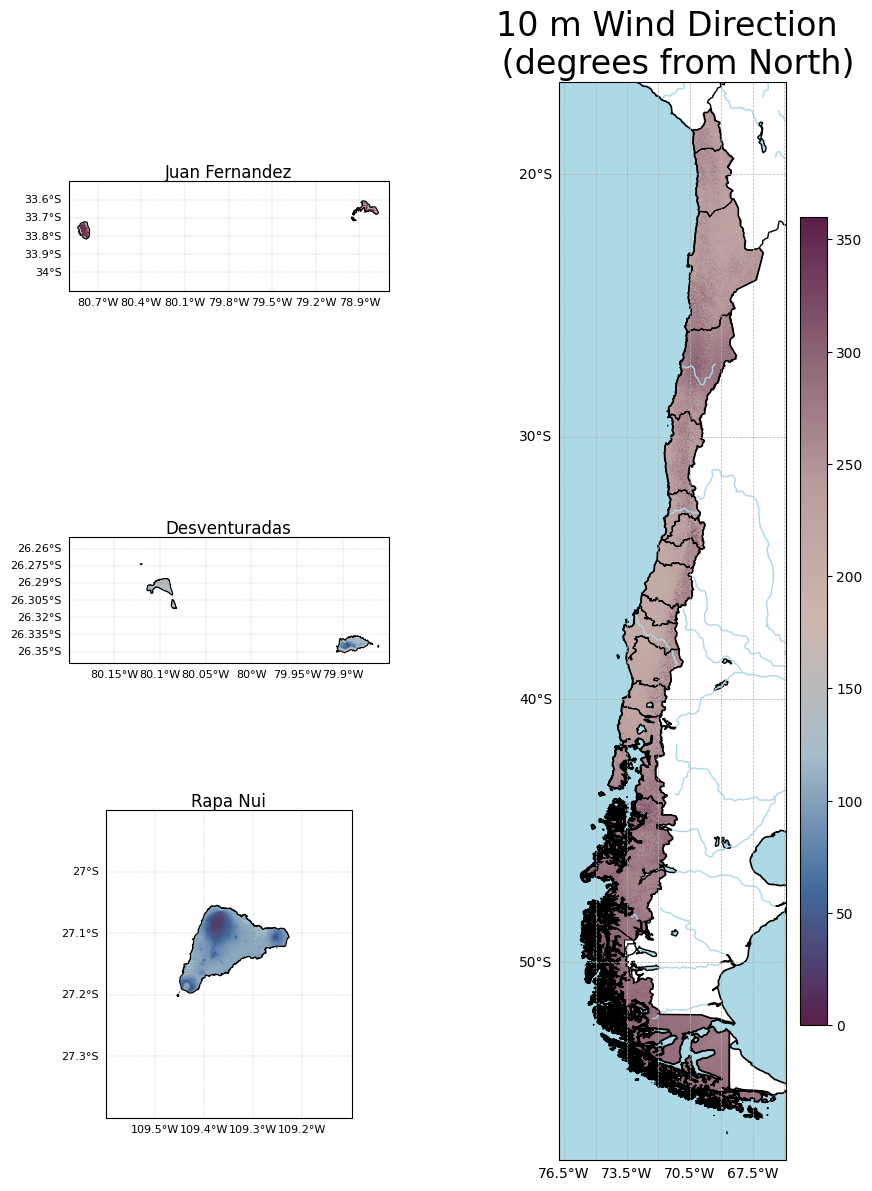

In [9]:
fig = draw_wind_map(
    continent_ds=xdf_continent,
    islands_ds=xdf_islands,
    variable_name="dir_integrated",
    vmin=0,
    vmax=360,
    cmap=wind_direction_cmap,
    label="",
    title="10 m Wind Direction \n (degrees from North)",
    figure_path=WIND_DIRECTION_FIGURE,
    inset_areas=INSET_AREAS if USE_ISLANDS else None,
)

## 8. Optional checks

Use these quick checks if something does not plot correctly.

In [ ]:
print("Continental variables:")
print(list(xdf_continent.data_vars))

print("Continental coordinates:")
print(list(xdf_continent.coords))

if USE_ISLANDS and xdf_islands is not None:
    print("Islands variables:")
    print(list(xdf_islands.data_vars))
    print("Islands coordinates:")
    print(list(xdf_islands.coords))